# 1. Imports y lectura del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
import sys
sys.path.append('..')

from dataset_processing.processor import reduce_aemet_df_to_clm

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [5]:
df = pd.read_parquet('../datasets/parquet/CURATED_AEMET.parquet').drop(columns=['presMax', 'presMin', 'presMedia'])
s_df = pd.read_csv('../datasets/csv/CURATED_AEMET_stations.csv')

In [6]:
# register_count = df[['indicativo', 'fecha']].value_counts()
# duplicados = (register_count > 1)
# duplicados.sum()

In [7]:
df_clm = pd.read_parquet('../datasets_clm/main/AEMET_ERA5_daily.parquet')
s_df_clm = pd.read_csv('../datasets_clm/aux/AEMET_stations.csv')

In [8]:
# register_count = df_clm[['indicativo', 'fecha']].value_counts()
# duplicados = (register_count > 1)
# duplicados.sum()

In [9]:
old_df_clm = pd.read_parquet('../datasets/parquet/AEMET_1970-01-01_2024-12-31.parquet')
old_s_df_clm = pd.read_csv('../datasets/csv/AEMET_stations.csv')
old_df_clm, old_s_df_clm = reduce_aemet_df_to_clm(old_df_clm, old_s_df_clm)

# 2. Clasificación de eventos climatológicos extremos

Para la determinación de umbrales de alerta, se usan una variedad de métodos que varían según la variable y el país. [Generalmente se usan umbrales para la definición de un extremo](https://www.ipcc.ch/report/ar6/wg1/chapter/chapter-11/), que pueden ser desde relativos a percentiles de la variable en un lugar y momento del año dados a lo largo de un periodo de referencia hasta absolutos, con distintas métricas para la medición de distintos extremos.

El AEMET tiene definidos umbrales para la declaración de las alertas amarilla, naranja y roja (se visualizan mejor en mapas del documento).

* [Umbrales de alerta](https://www.aemet.es/documentos/es/eltiempo/prediccion/avisos/plan_meteoalerta/METEOALERTA_ANX1_Umbrales_y_niveles_de_aviso.pdf)

* [Plan Meteoalerta](https://www.aemet.es/documentos/es/eltiempo/prediccion/avisos/plan_meteoalerta/plan_meteoalerta.pdf)

## 2.1. Clasificación de temperatura


En el caso de los sistemas de alerta de olas de calor, algunos ejemplos son métodos basados en excesos de mortalidad, métodos que evaluan el estrés térmico en humanos y métodos que escogen umbrales basados en percentiles de temperaturas, dependiendo del sistema de alerta y del país. En particular, se utiliza la mortalidad como determinante de cuándo se debe emitir un aviso por hora de calor porque existe una correlación entre mortalidad en exceso y temperaturas extremas, lo cual es apreciable en gráficos asociando residuales de mortalidad con temperatura máxima.
([Heatwaves and Health, 4.4, WMO](https://library.wmo.int/idurl/4/54600))

En el caso del AEMET, para declarar una ola de calor o frío en ámbito de estudio, se tiene el requisito de que se de en al menos un 10% de las estaciones consideradas los criterios:
* Temperaturas superiores a los 95-percentiles históricos entre 1971 y 2000 de meses julio y agosto -> temperaturas anormalmente altas para la clasificación de [olas de calor](https://www.aemet.es/documentos/es/conocermas/recursos_en_linea/publicaciones_y_estudios/estudios/Olas_calor/olas_calor_actualizacion_dic24.pdf). 137 estaciones consideradas (6 estaciones en Canarias).

* Temperaturas inferiores a los 5-percentiles históricos entre 1971 y 2000 de meses enero y febrero -> temperaturas anormalmente bajas para la clasificación de [olas de frío](https://www.aemet.es/documentos/es/conocermas/recursos_en_linea/publicaciones_y_estudios/estudios/Olas_frio/olas_frio_actualizacion_dic24.pdf). 131 estaciones consideradas (Canarias no se toma en cuenta).

Para este caso, al ser más una estudio del rendimiento de distintos modelos de *Machine Learning* que un estudio del impacto de las olas de calor o un sistema de aviso real, no se usarán datos de mortalidad o de estrés metabólico para determinar lo que se considera un extremo de temperatura. Por la variedad en los climas de las distintas regiones de España, no siendo lo mismo una temperatura de 35ºC en Murcia que en Galicia, se considera que el uso de umbrales relativos a cada estación meteorológica es adecuado.

## 2.2. Precipitación

No es posible usar una única definición de precipitación extrema, ya que los patrones de precipitación difieren considerablemente según la región. También son dependientes de la escala temporal, y se pueden dar a lo largo de minutos o a lo largo de días. Es por esto que generalmente se realiza la clasificación de precipitación extrema por:

* Umbrales absolutos con un cierto impacto asociado

* La rareza del evento en la forma de umbrales de los 90 a 99 percentiles

* El periodo de retorno de los eventos extremadamente raros (que se mide en años)

Lo recomendado por la WMO es la adopción de un umbral que se coreresponda con la necesidad de avisar del evento.
([Guidelines on the Definition and Charecterization of Extreme Weather and Climate Events, WMO](https://library.wmo.int/idurl/4/58396))

En el caso del [AEMET](https://www.aemet.es/documentos/es/eltiempo/prediccion/avisos/plan_meteoalerta/METEOALERTA_ANX1_Umbrales_y_niveles_de_aviso.pdf), existen dos periodos temporales para las alertas de precipitación:
* Precipitación acumulada en 1 hora
* Precipitacion acumulada en 12 horas

Los datos que se han obtenido de AEMET OpenData tienen una resolución temporal de 24 horas, por lo que no nos será posible saber con detalle la distribución de las precipitaciones registradas, que puede haberse distribuido uniformemente a lo largo del día o haber estado concentrada en un periodo de tiempo más corto.

## 2.3. Viento

Además de los umbrales basados en percentiles nombrados en las secciones anteriores, se han encontrado las siguientes maneras de clasificar el viento:

* La [escala de Beaufort](https://www.rmets.org/metmatters/beaufort-wind-scale) es una manera de estimar la velocidad del viento basado en fenomenos observables reconocida por el *National Weather Service* estadounidense. La asociación a la inversa (fenómenos a partir de velocidad del viento) puede sernos util. Establecen un vendaval (*gale*) como nivel 8, empezando por 39 millas por hora, 17.43 metros por segundo, que es cuando los efectos adversos empiezan (cayendo ramas que pueden ocasionar daños).

* Los [umbrales establecidos por la AEMET](https://www.aemet.es/documentos/es/eltiempo/prediccion/avisos/plan_meteoalerta/METEOALERTA_ANX1_Umbrales_y_niveles_de_aviso.pdf) para emitir los distintos avisos, que en la mayor parte de la península son 70/90/130 km/h (19.4/25/36.1 m/s) para los avisos amarillo/naranja/rojo.


# 3. España

Se va a hacer un ejemplo de los cálculos de umbrales para 5 estaciones meteorológicas aleatorias, con los parámetros:
* Umbrales globales: 99-percentil y 1-percentil
* Umbrales relativos al mes: 95-percentil y 1-percentil 

In [10]:
# Estaciones aleatorias
ids = df.loc[:, ['indicativo', 'nombre']].drop_duplicates().sample(4)
print(ids)

       indicativo                         nombre
44          9771C                         LLEIDA
286768      5000C                          CEUTA
286764      4116I                ALMAGRO / FAMET
47           B278  PALMA DE MALLORCA, AEROPUERTO


In [11]:
from dataset_labeling.labeler import build_daily_thresholds, label_rows
from dataset_labeling.config import EXTREME_TMAX_PERCENTILE, EXTREME_TMIN_PERCENTILE, EXTREME_WIND_PERCENTILE, EXTREME_PREC_PERCENTILE
print(EXTREME_TMAX_PERCENTILE, EXTREME_TMIN_PERCENTILE, EXTREME_WIND_PERCENTILE, EXTREME_PREC_PERCENTILE)

0.95 0.05 0.95 0.95


In [12]:
thresholds = build_daily_thresholds(df)
thresholds_subset = thresholds.merge(ids, on='indicativo', how='inner')
df = label_rows(df, thresholds)
df_subset = df.merge(ids['indicativo'], on='indicativo', how='inner')

In [13]:
# Da igual pillar solo un año para graficar umbrales, son iguales todos los años y solo cambian por diaAnio
plot_df = (
    df_subset[
        ['indicativo', 'nombre', 'mes', 'dia',
        'tmax_threshold', 'tmin_threshold',
        'prec_threshold',
        'velmedia_threshold', 'racha_threshold']
    ]
    .drop_duplicates()
    .sort_values(['indicativo', 'mes', 'dia'])
)

plot_df['indicativo'] = plot_df['indicativo'].cat.remove_unused_categories()
plot_df['nombre'] = plot_df['nombre'].cat.remove_unused_categories()

In [14]:
plot_df["fecha"] = pd.to_datetime(
    {
        "year": 2012, # bisiesto por incluir el 29 de febrero
        "month": plot_df["mes"],
        "day": plot_df["dia"],
    }
)

In [15]:
# Da igual pillar solo un año para graficar umbrales, son iguales todos los años y solo cambian por diaAnio
all_plot_df = (
    df[
        ['indicativo', 'nombre', 'mes', 'dia',
        'tmax_threshold', 'tmin_threshold',
        'prec_threshold',
        'velmedia_threshold', 'racha_threshold']
    ]
    .drop_duplicates()
    .sort_values(['indicativo', 'mes', 'dia'])
)

all_plot_df['indicativo'] = all_plot_df['indicativo'].cat.remove_unused_categories()
all_plot_df['nombre'] = all_plot_df['nombre'].cat.remove_unused_categories()

In [16]:
all_plot_df["fecha"] = pd.to_datetime(
    {
        "year": 2012, # bisiesto por incluir el 29 de febrero
        "month": all_plot_df["mes"],
        "day": all_plot_df["dia"],
    }
)

In [ ]:
def plot_thresholds(
        df, var, fsize=(10, 4),
        ylabel="Grados Celsius", xlim=None, ylim=None,
        aggregated=False, 
        ax=None,
        xlabel=None,
        xticks=None,
        title=None
):
    if not ax:
        fig, ax = plt.subplots(figsize=fsize)

    if not aggregated:
        sns.lineplot(
            data=df, x='fecha', y=var,
            hue='nombre', ax=ax, alpha=0.6,
        )
    else:
        sns.lineplot(
            data=df,
            x='fecha', y=var, ax=ax,
            estimator='median', errorbar=('pi', 90)
        )

    if xlabel: ax.set_xlabel('Día del año')
    ax.set_ylabel(ylabel)
    
    if title: 
        ax.set_title(title)

    if xticks:
        ax.xaxis.set_major_locator(mdates.MonthLocator())

        months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

        ticks = pd.date_range(start='2012-01-01', periods=12, freq='MS')

        ax.set_xticks(ticks)
        ax.set_xticklabels(months)

    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)

    if not ax:
        plt.tight_layout()
        plt.show()
    else:
        return ax                      

## 3.1. Ejemplo de temperatura

In [18]:
thresholds_subset[['indicativo', 'nombre', 'c_month', 'c_day', 'tmax_threshold', 'tmin_threshold']].describe()

,c_month,c_day,tmax_threshold,tmin_threshold
count,1464.000000,1464.000000,1464.000000,1464.000000
mean,6.513661,15.756831,26.965420,6.767234
std,3.452413,8.814541,7.201960,7.259146
min,1.000000,1.000000,14.400000,-7.920000
25%,4.000000,8.000000,20.615000,0.267500
50%,7.000000,16.000000,26.500000,7.887500
75%,10.000000,23.000000,33.403752,12.505000
max,12.000000,31.000000,41.445001,20.400000


<Axes: xlabel='fecha', ylabel='Grados Celsius'>

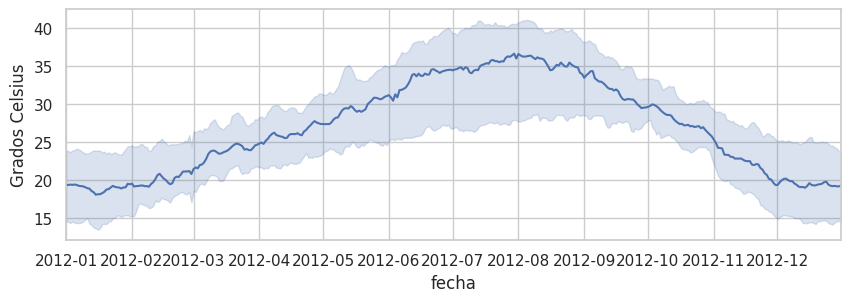

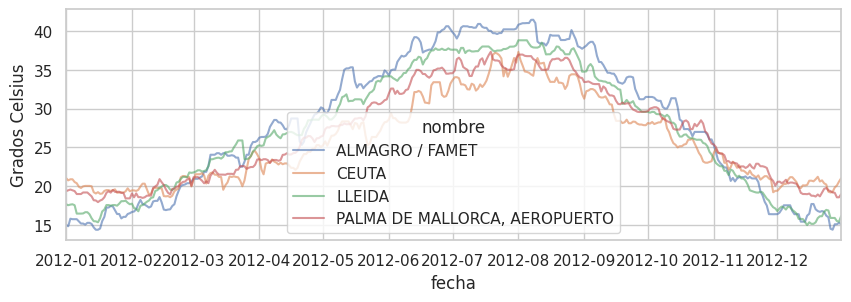

In [19]:
plot_thresholds(all_plot_df, "tmax_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "tmax_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

<Axes: xlabel='fecha', ylabel='Grados Celsius'>

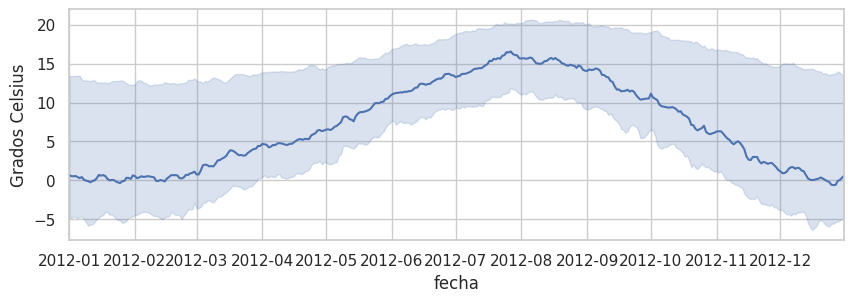

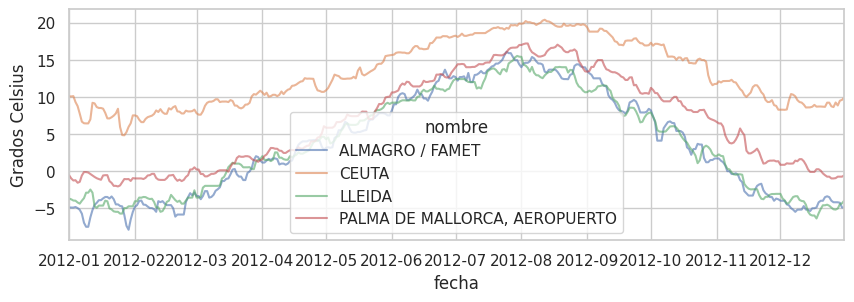

In [20]:
plot_thresholds(all_plot_df, "tmin_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "tmin_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

## 3.2. Ejemplo de precipitación

In [21]:
thresholds_subset[['indicativo', 'nombre', 'c_month', 'c_day', 'prec_threshold']].describe()

,c_month,c_day,prec_threshold
count,1464.000000,1464.000000,1464.000000
mean,6.513661,15.756831,7.726363
std,3.452413,8.814541,7.485415
min,1.000000,1.000000,0.000000
25%,4.000000,8.000000,2.175000
50%,7.000000,16.000000,6.247500
75%,10.000000,23.000000,10.701250
max,12.000000,31.000000,50.125001


<Axes: xlabel='fecha', ylabel='Milimetros'>

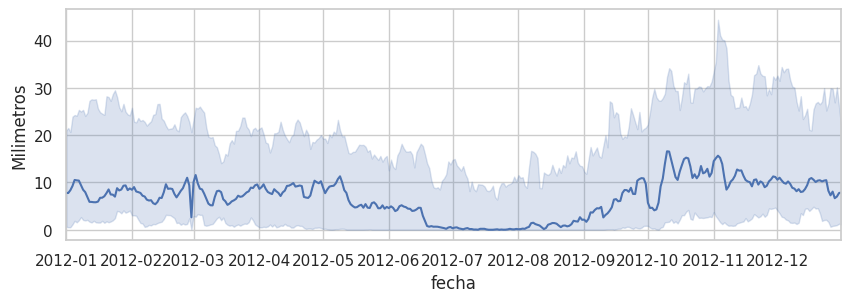

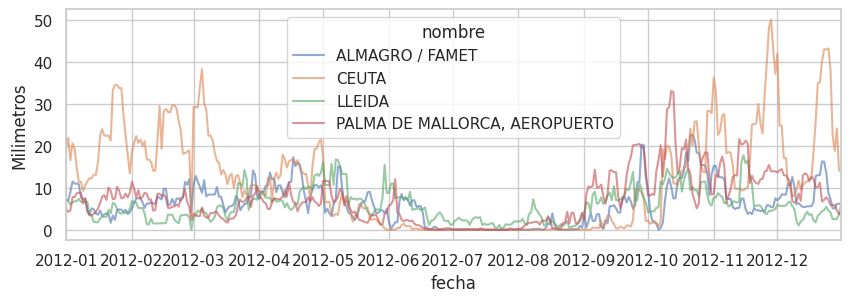

In [22]:
plot_thresholds(all_plot_df, "prec_threshold", fsize=(10, 3), ylabel="Milimetros", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "prec_threshold", fsize=(10, 3), ylabel="Milimetros", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

## 3.3. Ejemplo de velocidad de viento

<Axes: xlabel='fecha', ylabel='Metros por segundo'>

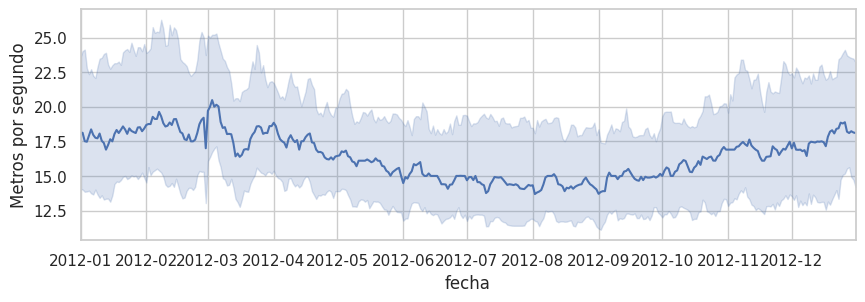

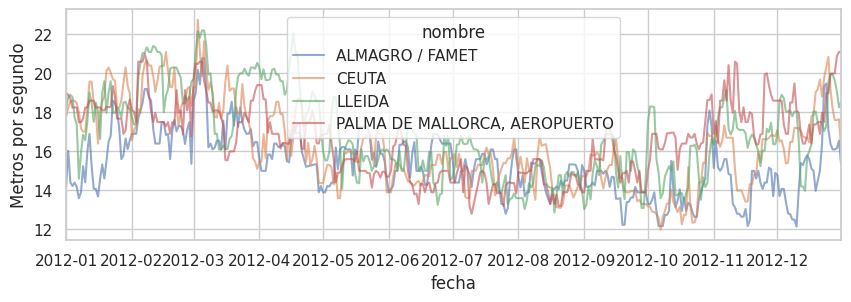

In [23]:
plot_thresholds(all_plot_df, "racha_threshold", fsize=(10, 3), ylabel="Metros por segundo", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "racha_threshold", fsize=(10, 3), ylabel="Metros por segundo", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

Hay que ver si los registros con rachas de aire altas se corresponden con los de velocidades medias altas, al haber en general menores valores nulos en las velocidades de aire medias. Se agruparan todas las mediciones por fecha y se compararán.

In [24]:
print(f'Las variables racha y velmedia tienen una correlación del {df['racha'].corr(df['velmedia'])}')

Las variables racha y velmedia tienen una correlación del 0.7491545064582832


Están fuertemente correlacionadas, pero no perfectamente, por lo que no son intercambiables.

## 3.4. Todas

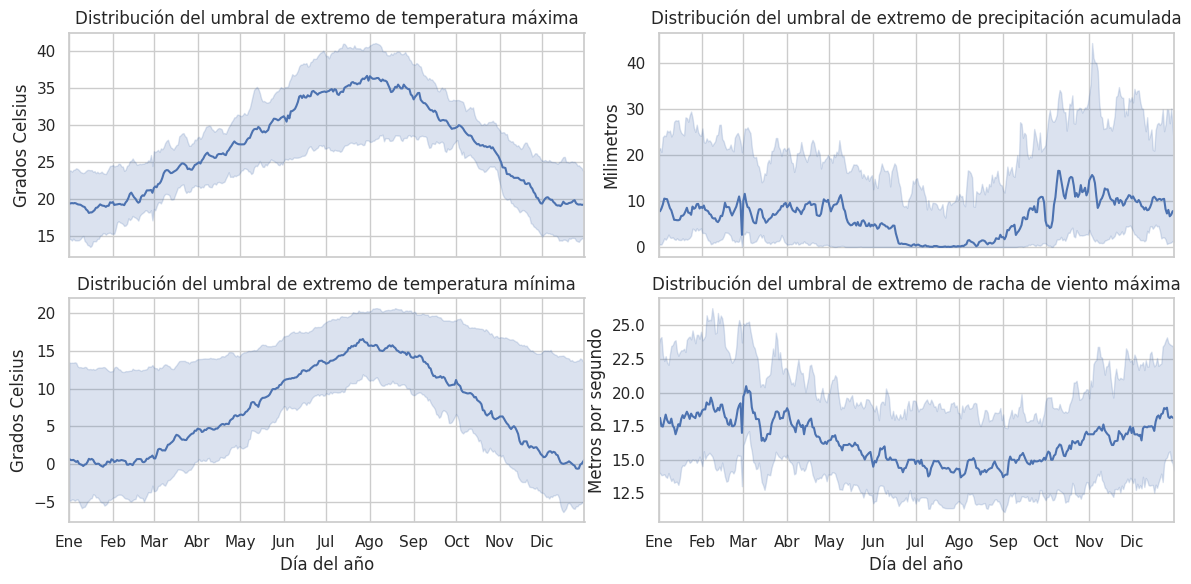

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

plot_thresholds(all_plot_df, "tmax_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[0][0], title="Distribución del umbral de extremo de temperatura máxima"
)
plot_thresholds(all_plot_df, "tmin_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[1][0], title="Distribución del umbral de extremo de temperatura mínima",
    xticks=True, xlabel=True
)

plot_thresholds(all_plot_df, "prec_threshold", fsize=(10, 3), ylabel="Milimetros", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[0][1], title="Distribución del umbral de extremo de precipitación acumulada"
)
plot_thresholds(all_plot_df, "racha_threshold", fsize=(10, 3), ylabel="Metros por segundo", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[1][1], title="Distribución del umbral de extremo de racha de viento máxima",
    xticks=True, xlabel=True
)

# fig.suptitle("Distribución de umbrales de extremo en España")

plt.tight_layout()
plt.show()

Hay un total de 62324 registros con umbral de precipitación igual a 0 de 799338 registros


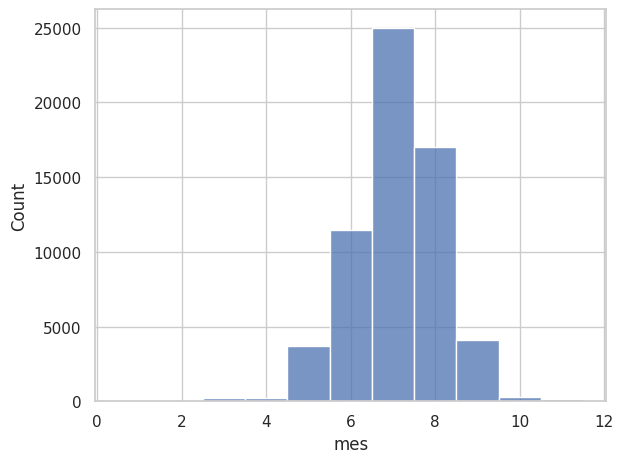

In [26]:
prec_zeros = df.loc[
    (df['anio'] <= 2018)
    & (df['prec_threshold'] == 0)
]
print(f"Hay un total de {prec_zeros.shape[0]} registros con umbral de precipitación igual a 0 de {df.shape[0]} registros")
sns.histplot(data=prec_zeros, x='mes', discrete=True)
plt.tight_layout(); plt.show()

# 4. CLM

Para estos valores, se va a mirar la diferencia entre los sacados de ERA5 y los obtenidos del AEMET.

Las unidades son las siguientes:

* Temperatura: K (vs C)
* Velocidad de viento: m/s (igual)
* Precipitación: m (vs mm)

In [27]:
# Estaciones aleatorias
ids = df_clm.loc[:, ['indicativo']].drop_duplicates().sample(4)
ids = ids.merge(s_df_clm[['indicativo', 'nombre']], on='indicativo')
print(ids)

  indicativo                      nombre
0      3168C  GUADALAJARA, EL SERRANILLO
1      4147X                  VALDEPEÑAS
2      3254Y                        MORA
3      4116I             ALMAGRO / FAMET


In [28]:
thresholds_clm = build_daily_thresholds(df_clm)
thresholds_clm_subset = thresholds_clm.merge(ids, on='indicativo', how='inner')
df_clm = label_rows(df_clm, thresholds_clm)
df_subset = df_clm.merge(ids['indicativo'], on='indicativo', how='inner')

In [29]:
plot_df = (
    df_subset.loc[
        df_subset['anio'] == 2012, # año bisiesto, por incluir 2-29
        ['indicativo', 'nombre', 'fecha',
        'tmax_threshold', 'tmin_threshold',
        'prec_threshold',
        'velmedia_threshold', 'racha_threshold']
    ]
    .drop_duplicates()
    .sort_values(['indicativo', 'fecha'])
)

In [30]:
all_plot_df = (
    df_clm.loc[
        df_clm['anio'] == 2012, # año bisiesto, por incluir 2-29
        ['indicativo', 'nombre', 'fecha',
        'tmax_threshold', 'tmin_threshold',
        'prec_threshold',
        'velmedia_threshold', 'racha_threshold']
    ]
    .drop_duplicates()
    .sort_values(['indicativo', 'fecha'])
)

In [31]:
all_plot_df

,indicativo,nombre,fecha,tmax_threshold,tmin_threshold,prec_threshold,velmedia_threshold,racha_threshold
32313,3013,MOLINA DE ARAGÓN,2012-01-01,288.529987,263.189990,0.002185,4.200000,15.260000
32357,3013,MOLINA DE ARAGÓN,2012-01-02,288.349994,263.770001,0.007600,4.200000,16.040000
32399,3013,MOLINA DE ARAGÓN,2012-01-03,288.229999,263.970001,0.007600,4.200000,16.040000
32442,3013,MOLINA DE ARAGÓN,2012-01-04,288.569995,264.549982,0.008800,4.200000,15.760000
32485,3013,MOLINA DE ARAGÓN,2012-01-05,288.729999,264.949982,0.008800,4.640000,15.420000
...,...,...,...,...,...,...,...,...
50934,9377Y,EL PEDREGAL,2012-12-27,291.409998,267.921631,0.004000,5.667288,16.580001
50988,9377Y,EL PEDREGAL,2012-12-28,291.409998,267.842993,0.000365,5.640000,16.040000
51042,9377Y,EL PEDREGAL,2012-12-29,289.730005,268.242993,0.000675,5.000000,15.800000
51096,9377Y,EL PEDREGAL,2012-12-30,288.850006,267.910004,0.000960,4.962037,16.580001


Conversión de unidades a Celsius y 

In [32]:
plot_df[['tmax_threshold', 'tmin_threshold']] = plot_df[['tmax_threshold', 'tmin_threshold']] - 273.15
plot_df['prec_threshold'] = plot_df['prec_threshold'] * 1000 

all_plot_df[['tmax_threshold', 'tmin_threshold']] = all_plot_df[['tmax_threshold', 'tmin_threshold']] - 273.15
all_plot_df['prec_threshold'] = all_plot_df['prec_threshold'] * 1000 

In [33]:
thresholds_clm_subset[['indicativo', 'nombre', 'c_month', 'c_day', 'tmax_threshold', 'tmin_threshold', 'prec_threshold', 'racha_threshold', 'velmedia_threshold']]

,indicativo,nombre,c_month,c_day,tmax_threshold,tmin_threshold,prec_threshold,racha_threshold,velmedia_threshold
0,3168C,"GUADALAJARA, EL SERRANILLO",1,1,287.149994,265.989984,0.003355,12.568304,4.335122
1,3168C,"GUADALAJARA, EL SERRANILLO",1,2,287.789984,266.169983,0.004731,15.048523,4.523615
2,3168C,"GUADALAJARA, EL SERRANILLO",1,3,287.549994,267.069989,0.004731,15.048523,4.523615
3,3168C,"GUADALAJARA, EL SERRANILLO",1,4,287.889984,267.229993,0.007123,12.549392,4.502236
4,3168C,"GUADALAJARA, EL SERRANILLO",1,5,287.949982,267.229993,0.007123,13.549192,5.051931
...,...,...,...,...,...,...,...,...,...
1459,4147X,VALDEPEÑAS,12,27,289.029999,269.289996,0.003640,14.380000,4.080000
1460,4147X,VALDEPEÑAS,12,28,289.029999,269.169995,0.003480,13.040000,3.540000
1461,4147X,VALDEPEÑAS,12,29,288.950000,267.829999,0.003480,13.040000,3.300000
1462,4147X,VALDEPEÑAS,12,30,288.969989,267.789996,0.002680,14.320000,3.300000


## 4.1. Ejemplo de temperatura

<Axes: xlabel='fecha', ylabel='Grados Celsius'>

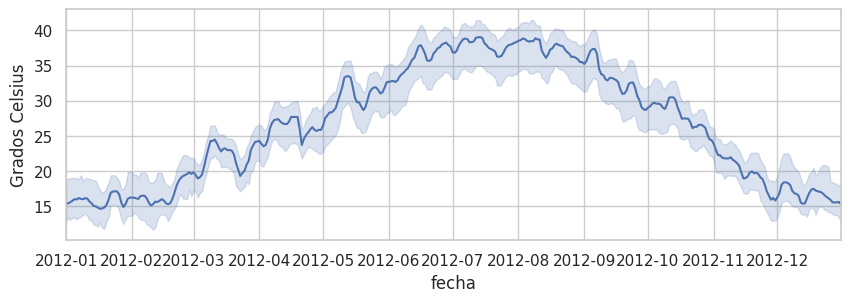

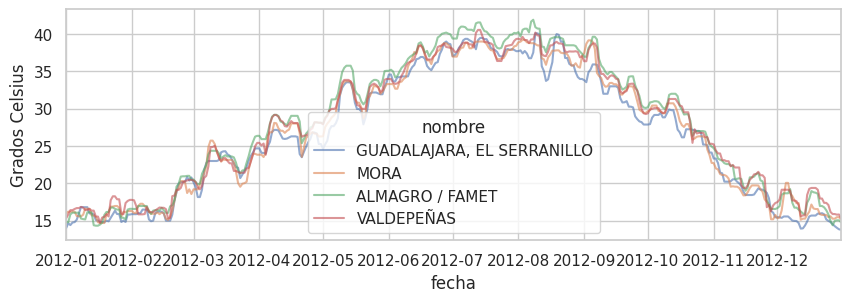

In [34]:
plot_thresholds(all_plot_df, "tmax_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "tmax_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

<Axes: xlabel='fecha', ylabel='Grados Celsius'>

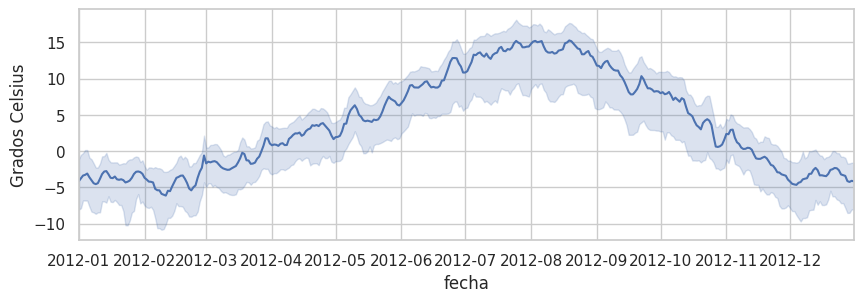

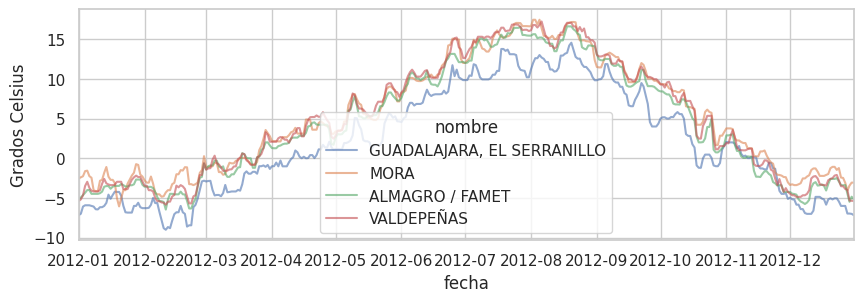

In [35]:
plot_thresholds(all_plot_df, "tmin_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "tmin_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

## 4.2. Ejemplo de precipitación

<Axes: xlabel='fecha', ylabel='Milímetros'>

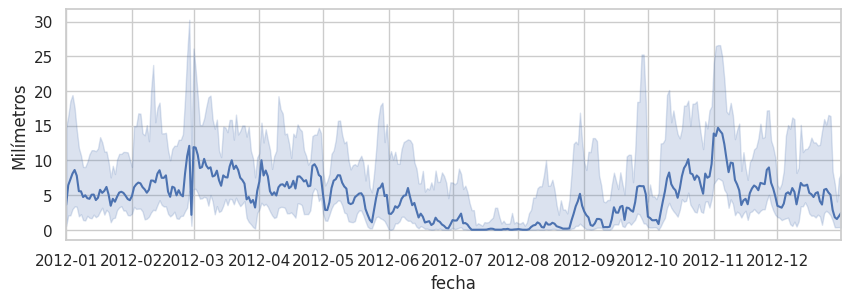

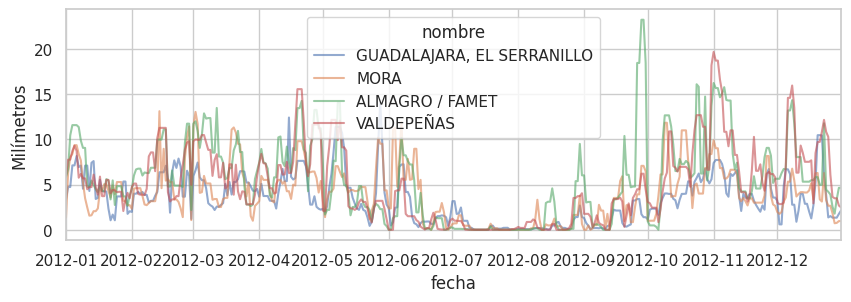

In [36]:
plot_thresholds(all_plot_df, "prec_threshold", fsize=(10, 3), ylabel="Milímetros", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "prec_threshold", fsize=(10, 3), ylabel="Milímetros", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

## 4.3. Ejemplo de velocidad de viento

<Axes: xlabel='fecha', ylabel='Metros por segundo'>

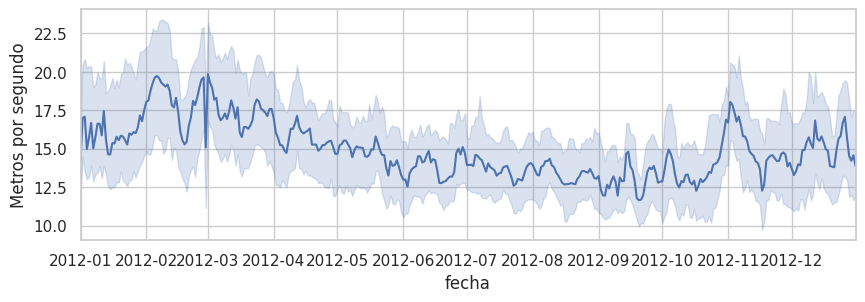

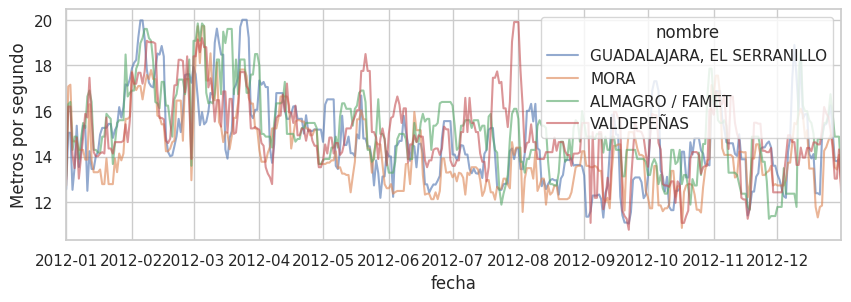

In [37]:
plot_thresholds(all_plot_df, "racha_threshold", fsize=(10, 3), ylabel="Metros por segundo", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True
)

plot_thresholds(plot_df, "racha_threshold", fsize=(10, 3), ylabel="Metros por segundo", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=False
)

## 4.4. Todas

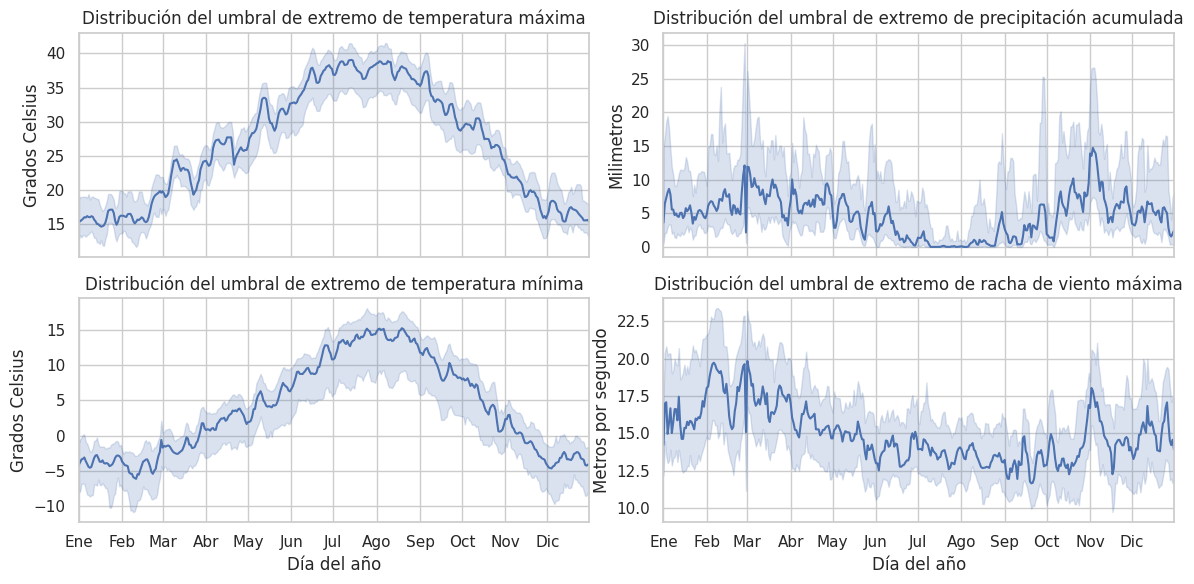

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

plot_thresholds(all_plot_df, "tmax_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[0][0], title="Distribución del umbral de extremo de temperatura máxima"
)
plot_thresholds(all_plot_df, "tmin_threshold", fsize=(10, 3), ylabel="Grados Celsius", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[1][0], title="Distribución del umbral de extremo de temperatura mínima",
    xticks=True, xlabel=True
)

plot_thresholds(all_plot_df, "prec_threshold", fsize=(10, 3), ylabel="Milimetros", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[0][1], title="Distribución del umbral de extremo de precipitación acumulada"
)
plot_thresholds(all_plot_df, "racha_threshold", fsize=(10, 3), ylabel="Metros por segundo", 
    xlim=(pd.to_datetime('2012-01-01'), pd.to_datetime('2012-12-31')),
    aggregated=True, ax=axes[1][1], title="Distribución del umbral de extremo de racha de viento máxima",
    xticks=True, xlabel=True
)

# fig.suptitle("Distribución de umbrales de extremo en CLM")

plt.tight_layout()
plt.show()

Hay un total de 32244 registros con umbral de precipitación igual a 0 de 799338 registros


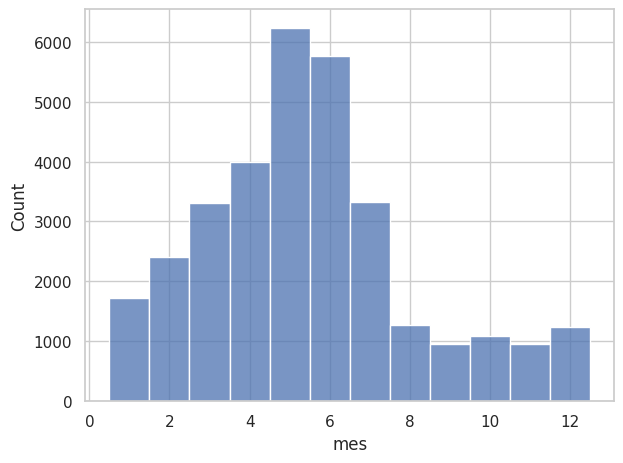

In [39]:
prec_zeros = df_clm.loc[
    (df['anio'] <= 2018)
    & (df['prec_threshold'] == 0)
]
print(f"Hay un total de {prec_zeros.shape[0]} registros con umbral de precipitación igual a 0 de {df.shape[0]} registros")
sns.histplot(data=prec_zeros, x='mes', discrete=True)
plt.tight_layout(); plt.show()

## 4.5. Comparación AEMET - ERA5

### 4.5.1. Cálculo de diferencias entre AEMET y ERA5

In [40]:
full_df = pd.read_parquet('../datasets_clm/main/ERA5_daily.parquet')
imputed_df = pd.read_parquet('../datasets_clm/main/AEMET_ERA5_daily.parquet')

In [41]:
from dataset_processing import processor
from dataset_labeling import labeler

In [42]:
idx = ['indicativo', 'fecha']

In [43]:
data_aemet = processor.adjust_pressures(old_df_clm)
data_aemet = processor.match_era5_units(data_aemet)

In [44]:
imputed_thresholds = labeler.build_daily_thresholds(imputed_df)
imputed_labeled_df = labeler.label_rows(imputed_df, imputed_thresholds)

aemet_thresholds = labeler.build_daily_thresholds(data_aemet)
aemet_labeled_df = labeler.label_rows(data_aemet, aemet_thresholds)

In [45]:
imputed_labeled_df.set_index(idx, drop=True)
aemet_labeled_df.set_index(idx, drop=True)

threshold_cols =['tmax_threshold', 'tmin_threshold', 'prec_threshold', 'velmedia_threshold', 'racha_threshold']

# Si pasa de 40 a 37 tras imputación, diff = 37 - 40 = -3 parece representarlo mejor
aemet_labeled_df[[col + '_diff' for col in threshold_cols]] = imputed_labeled_df[threshold_cols] - aemet_labeled_df[threshold_cols] 
aemet_labeled_df[[col + '_diff' for col in threshold_cols]].head()

,tmax_threshold_diff,tmin_threshold_diff,prec_threshold_diff,velmedia_threshold_diff,racha_threshold_diff
0,-0.270004,0.304996,0.000743,NaN,NaN
1,-0.150003,0.169998,-0.001305,NaN,NaN
2,0.000000,0.000000,0.000360,0.00,0.00
3,-0.050000,0.019998,-0.000020,-0.21,0.00
4,-0.110001,0.069995,-0.000040,0.18,0.15


In [46]:
import math

def boxplots_cols(df, cols, n_col=2, title="Diferencia entre observación e imputación"):
    n = len(cols)
    n_row = math.ceil(n / n_col)
    fig, axes = plt.subplots(
        nrows=n_row, ncols=n_col,
        sharex=True, figsize=(4 * n_col, 3 * n_row)
    )
    axes[0].set_title(title)
    # axes.title(title)
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel(col)
    for ax in axes[n:]:  
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def kdeplots_overlay(df, cols, title="Diferencia entre observación e imputación", figsize=(8,5), alpha=0.7, xlabel="Kelvin", color=None, legend=True):
    plt.figure(figsize=figsize)
    for col in cols:
        # sns.histplot(x=df[col], stat="count", label=col, alpha=0.5, kde=True)
        if color: 
            sns.kdeplot(x=df[col], fill=True, alpha=alpha, label=col, color=color)
        else:
            sns.kdeplot(x=df[col], fill=True, alpha=alpha, label=col)
    
    if legend: plt.legend()
    plt.title(title)
    
    plt.ylabel("Densidad")
    plt.xlabel(xlabel)

    plt.tight_layout()
    plt.show()

def hist_overlay(df, cols, title="Diferencia entre observación e imputación", figsize=(8,5), alpha=0.7, nbins=None, xlim=None, ylim=None, xlabel="Kelvin", color=None, legend=True):
    plt.figure(figsize=figsize)
    for col in cols:
        if nbins:
            if color:
                sns.histplot(x=df[col], stat="count", label=col, alpha=alpha, bins=nbins, color=color)
            else:
                sns.histplot(x=df[col], stat="count", label=col, alpha=alpha, bins=nbins)
        else:
            if color:
                sns.histplot(x=df[col], stat="count", label=col, alpha=alpha, color=color)
            else:
                sns.histplot(x=df[col], stat="count", label=col, alpha=alpha)
    
    if legend: plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.ylabel("Conteo")
    plt.xlabel(xlabel)

    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)

    plt.show()


### 4.5.2. Diferencia entre calcular umbrales solo con datos de AEMET vs con datos de ERA5 

(comprobado solo en registros con umbrales existentes de AEMET)

In [47]:
diffs_thresholds = aemet_labeled_df.loc[aemet_labeled_df['anio'] == 2012, ['indicativo', 'diaAnio', 'tmax_threshold_diff', 'tmin_threshold_diff', 'prec_threshold_diff', 'velmedia_threshold_diff', 'racha_threshold_diff']].drop_duplicates()

#### `tmax` y `tmin`

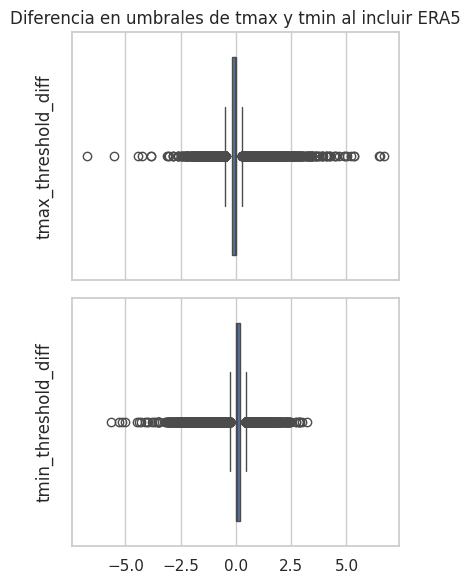

In [48]:
boxplots_cols(
    diffs_thresholds,
    ['tmax_threshold_diff', 'tmin_threshold_diff'],
    title="Diferencia en umbrales de tmax y tmin al incluir ERA5",
    n_col=1,
)

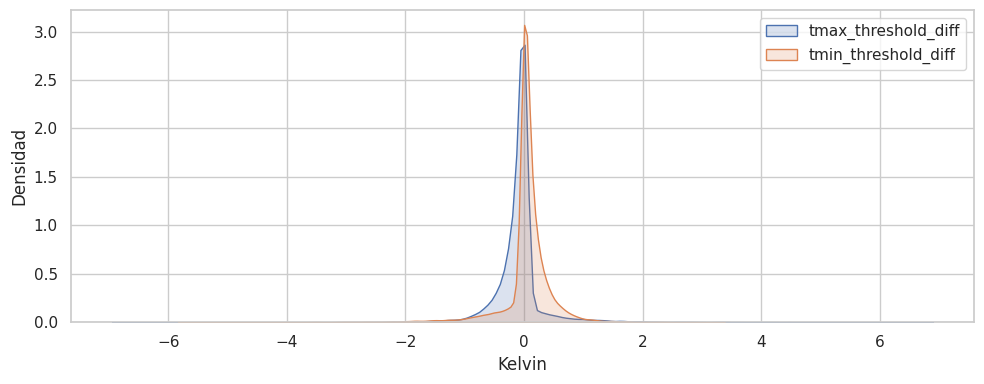

In [114]:
kdeplots_overlay(
    diffs_thresholds,
    ['tmax_threshold_diff', 'tmin_threshold_diff'],
    title="",
    figsize=(10, 4),
    alpha=0.2,
    xlabel="Kelvin",
)

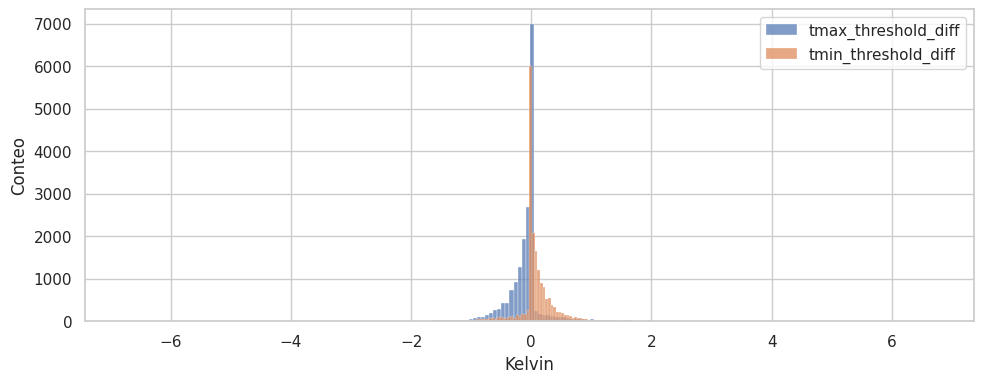

In [116]:
hist_overlay(
    diffs_thresholds,
    ['tmax_threshold_diff', 'tmin_threshold_diff'],
    # title="Diferencia en umbrales de tmax y tmin al incluir ERA5 (truncado sin casos extremos)",
    title="",
    figsize=(10, 4),
    nbins=200,
    # xlim=(-3, 3),
    alpha=0.7,
    # ylim=(0, 100),
    xlabel="Kelvin",
)

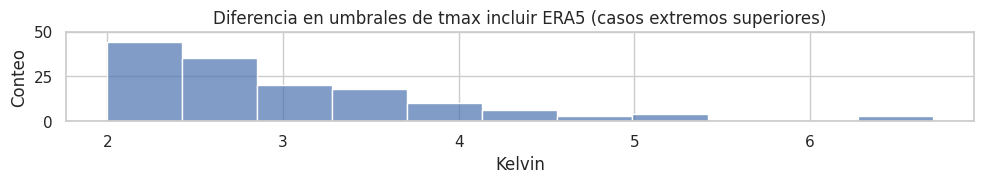

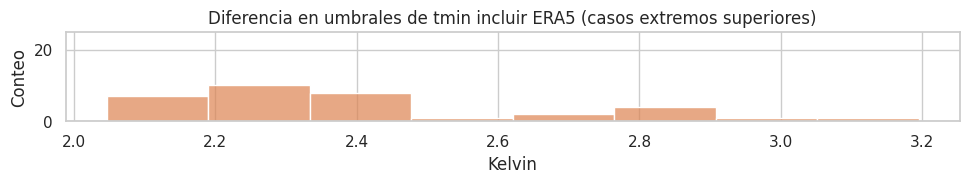

In [51]:
hist_overlay(
    diffs_thresholds[
        (diffs_thresholds["tmax_threshold_diff"] > 2)
    ],
    ['tmax_threshold_diff'],
    title="Diferencia en umbrales de tmax incluir ERA5 (casos extremos superiores)",
    figsize=(10, 2),
    # nbins=10,
    # xlim=(2, 10),
    ylim=(0, 50),
    xlabel="Kelvin",
    legend=False
)

hist_overlay(
    diffs_thresholds[
        (diffs_thresholds["tmin_threshold_diff"] > 2)
    ],
    ['tmin_threshold_diff'],
    title="Diferencia en umbrales de tmin incluir ERA5 (casos extremos superiores)",
    figsize=(10, 2),
    # nbins=10,
    # xlim=(2, 8),
    ylim=(0, 25),
    xlabel="Kelvin",
    color='#DD8452',
    legend=False
)

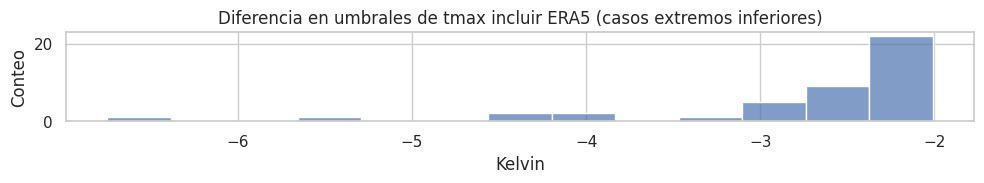

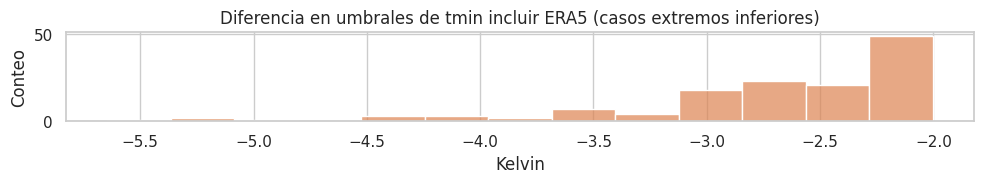

In [52]:
hist_overlay(
    diffs_thresholds[
        (diffs_thresholds["tmax_threshold_diff"] < -2)
    ],
    ['tmax_threshold_diff'],
    title="Diferencia en umbrales de tmax incluir ERA5 (casos extremos inferiores)",
    figsize=(10, 2),
    # nbins=10,
    # xlim=(-6, -2),
    # ylim=(0, 200),
    xlabel="Kelvin",
    legend=False
)

hist_overlay(
    diffs_thresholds[
        (diffs_thresholds["tmin_threshold_diff"] < -2)
    ],
    ['tmin_threshold_diff'],
    title="Diferencia en umbrales de tmin incluir ERA5 (casos extremos inferiores)",
    figsize=(10, 2),
    # nbins=10,
    # xlim=(-6, -2),
    # ylim=(0, 200),
    xlabel="Kelvin",
    color='#DD8452',
    legend=False
)

#### `racha` y `velmedia`

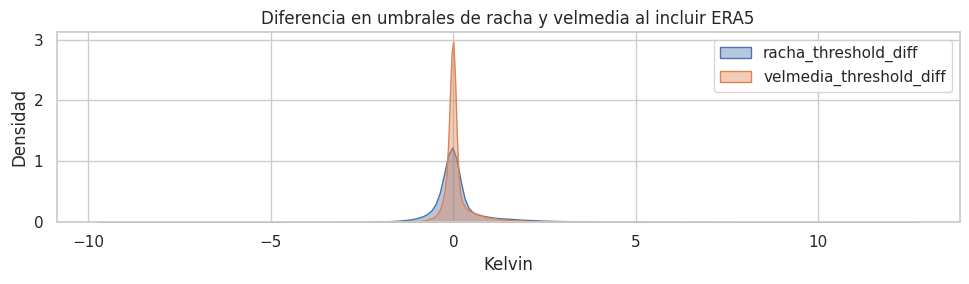

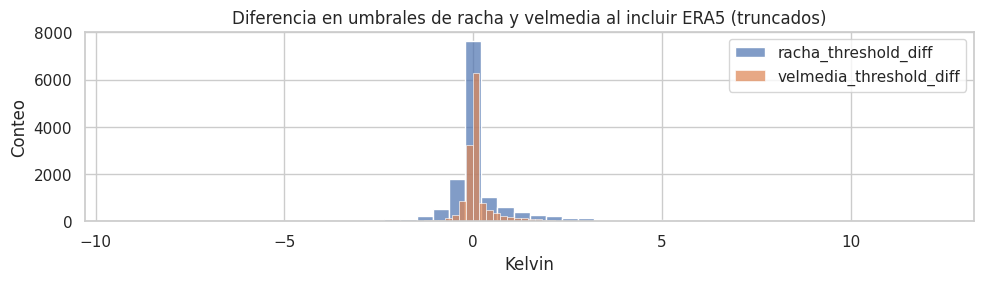

In [53]:
# boxplots_cols(
#     diffs_thresholds,
#     ['racha_threshold_diff', 'velmedia_threshold_diff'],
#     title="Diferencia en thresholds de racha y velmedia al incluir ERA5",
#     n_col=2
# )

kdeplots_overlay(
    diffs_thresholds,
    ['racha_threshold_diff', 'velmedia_threshold_diff'],
    title="Diferencia en umbrales de racha y velmedia al incluir ERA5",
    figsize=(10, 3), 
    alpha=0.4
)

hist_overlay(
    diffs_thresholds,
    ['racha_threshold_diff', 'velmedia_threshold_diff'],
    title="Diferencia en umbrales de racha y velmedia al incluir ERA5 (truncados)",
    figsize=(10, 3),
    # xlim=(-4, 4),
    nbins=50
)

#### `prec`

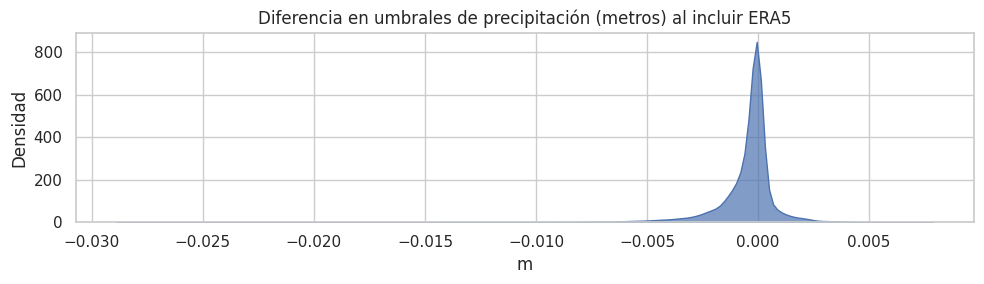

In [54]:
kdeplots_overlay(
    diffs_thresholds,
    ['prec_threshold_diff'],
    title="Diferencia en umbrales de precipitación (metros) al incluir ERA5",
    xlabel='m',
    figsize=(10, 3),
    legend=False
)

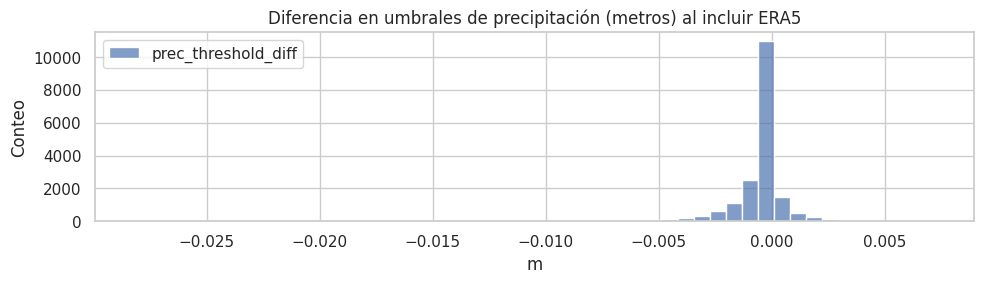

In [55]:
hist_overlay(
    diffs_thresholds,
    ['prec_threshold_diff'],
    title="Diferencia en umbrales de precipitación (metros) al incluir ERA5",
    figsize=(10, 3),
    xlabel='m',
    # xlim=(-0.05, 0.05),
    nbins=50
)

### 4.5.3. Diferencia entre observaciones AEMET y datos ERA5

In [56]:
data_aemet = data_aemet.set_index(idx, drop=True)
data_era5 = full_df.set_index(idx, drop=True)

num_cols = ['mslp_media', 'mslp_max', 'mslp_min', 'racha', 'tmed', 'tmin', 'tmax', 'prec', 'velmedia', 'hrMedia']
error_cols = [col + '_error' for col in num_cols]
abs_error_cols = [col + '_abs' for col in error_cols]

In [57]:
data_aemet[error_cols] = (data_era5[num_cols] - data_aemet[num_cols])# .abs()
data_aemet[abs_error_cols] = data_aemet[error_cols].abs()
no_nan_idx = data_aemet[error_cols + abs_error_cols].notna().all(axis=1)
data_aemet.loc[no_nan_idx, num_cols+error_cols].head()

,,mslp_media,mslp_max,mslp_min,racha,tmed,tmin,tmax,prec,velmedia,hrMedia,mslp_media_error,mslp_max_error,mslp_min_error,racha_error,tmed_error,tmin_error,tmax_error,prec_error,velmedia_error,hrMedia_error
indicativo,fecha,,,,,,,,,,,,,,,,,,,,
3168C,2010-01-01,98923.687500,99485.757812,98361.625000,13.100000,277.549988,274.250000,280.850006,0.0,5.0,100.0,2099.867188,2143.179688,2289.375000,2.988256,0.003998,0.400146,-1.387360,0.000234,-0.448452,-22.752861
3260B,2010-01-01,101266.476562,101782.414062,100750.546875,21.400000,280.850006,277.949982,283.750000,0.0,7.5,75.0,-93.015625,-56.226562,119.953125,-3.064672,-1.284302,-1.511261,-2.334229,0.000181,-1.101852,6.930995
3365A,2010-01-01,101391.578125,101888.359375,100894.789062,17.799999,281.149994,277.949982,284.250000,0.0,4.7,80.0,-183.273438,-147.671875,28.210938,-2.409984,-1.795715,-1.536163,-2.582275,0.000858,0.420604,8.405329
4067,2010-01-01,101248.304688,101775.500000,100721.109375,21.400000,279.449982,276.449982,282.449982,0.0,7.2,78.0,4.906250,-22.312500,231.890625,-3.217993,-0.177979,-0.573761,-1.836945,0.000083,-0.267077,2.147070
4103X,2010-01-01,101417.640625,101905.171875,100930.109375,19.700001,279.250000,276.549988,281.949982,0.0,5.0,81.0,-108.242188,-131.734375,72.140625,0.124584,0.659943,-0.200623,-0.788116,0.000165,1.731009,-5.218613


In [58]:
missing = pd.read_parquet('../datasets_clm/aux/AEMET_missing_days.parquet')
missing_num = len(missing)
missing_num

39406

#### 4.5.2.1. Valores faltantes por variable tras contar registros perdidos

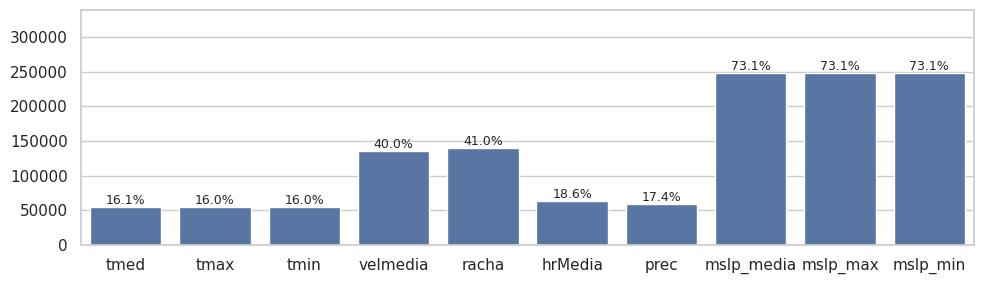

In [59]:
missing_per_var = (data_aemet.isna().sum(axis=0) + missing_num)
missing_per_var.drop(
    index=[col for col in missing_per_var.index if col not in num_cols],
    inplace=True
)

fig, ax = plt.subplots(figsize=(10, 3))

sns.barplot(
    x=missing_per_var.index,
    y=missing_per_var.values,
    ax=ax
)

total = len(data_era5)

# Añadir porcentaje encima de cada barra
for bar, value in zip(ax.patches, missing_per_var.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{100 * value / total:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xlabel("")
ax.set_ylim(0, total)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### 4.5.2.2. Errores entre observaciones e imputaciones

In [66]:
# kdeplots_overlay(
#     data_aemet,
#     ['tmed_error_abs', 'tmax_error_abs', 'tmin_error_abs'],
#     figsize=(10, 3),
#     title='Error absoluto entre observacón e imputación',
#     alpha=0.4
# )

# hist_overlay(
#     data_aemet,
#     ['tmax_error_abs'],
#     figsize=(10, 3),
#     alpha=None,
#     nbins=100,
#     title='Error absoluto entre observacón e imputación de tmax',
#     legend=False
# )

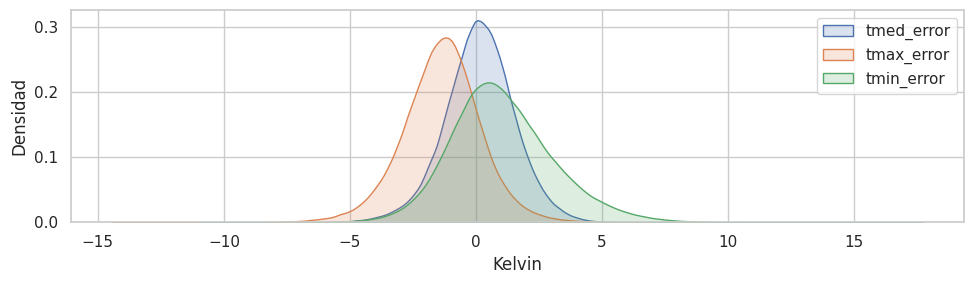

In [106]:
kdeplots_overlay(
    data_aemet,
    ['tmed_error', 'tmax_error', 'tmin_error'],
    figsize=(10, 3),
    # title='Diferencia entre observacón e imputación',
    title="",
    alpha=0.2,
)

# hist_overlay(
#     data_aemet,
#     ['tmax_error'],
#     figsize=(10, 3),
#     alpha=None,
#     nbins=100,
#     # title='Diferencia entre observacón e imputación de tmax',
#     title="",
#     legend=False,
    
# )

In [67]:
# kdeplots_overlay(
#     data_aemet,
#     ['prec_error_abs'],
#     figsize=(10, 3),
#     legend=False,
#     title='Error absoluto entre observacón e imputación de precipitación',
#     xlabel='Metros'
# )

# hist_overlay(
#     data_aemet,
#     ['prec_error_abs'],
#     figsize=(10, 3),
#     # alpha=0.6,
#     nbins=100,
#     title='Error absoluto entre observacón e imputación de precipitación',
#     legend=False,
#     xlabel='Metros'
# )

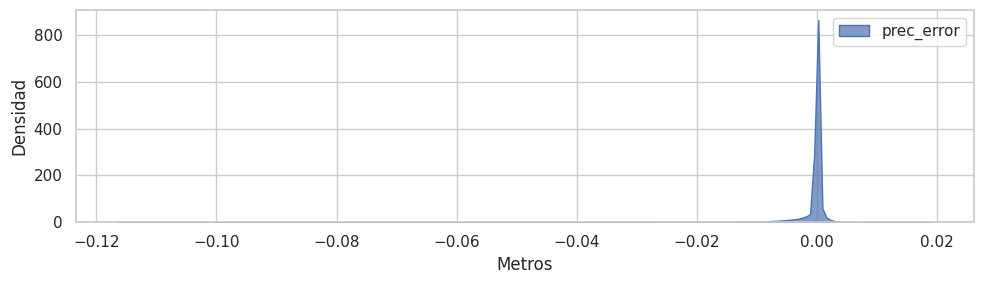

In [92]:
kdeplots_overlay(
    data_aemet,
    ['prec_error'],
    figsize=(10, 3),
    # title='Diferencia entre observacón e imputación',
    title="",
    # alpha=0.1,
    xlabel="Metros",
)

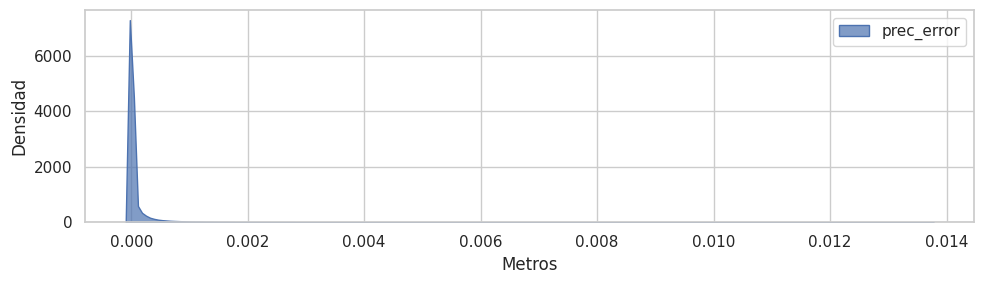

In [91]:
kdeplots_overlay(
    data_aemet[data_aemet["prec"] == 0],
    ['prec_error'],
    figsize=(10, 3),
    # title='Diferencia entre observacón e imputación',
    title="",
    # alpha=0.1,
    xlabel="Metros",
)

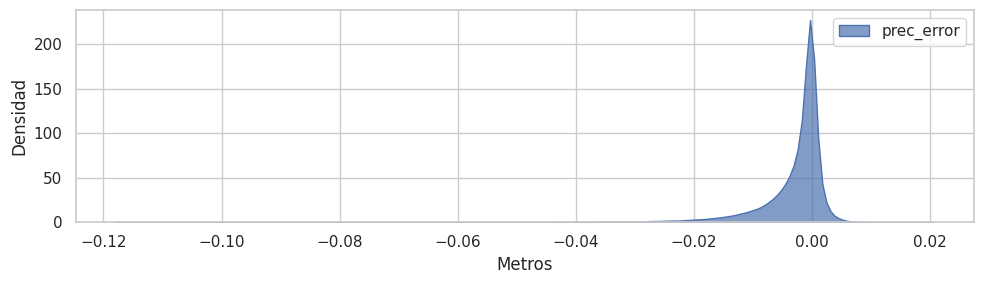

In [94]:
kdeplots_overlay(
    data_aemet[data_aemet["prec"] > 0],
    ['prec_error'],
    figsize=(10, 3),
    # title='Diferencia entre observacón e imputación',
    title="",
    # alpha=0.1,
    xlabel="Metros",
)

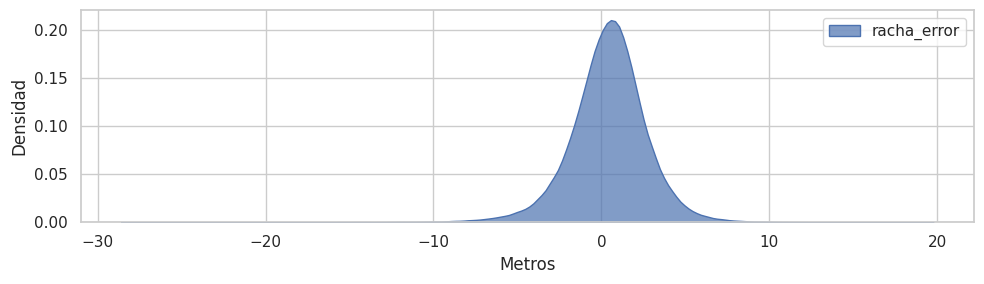

In [89]:
kdeplots_overlay(
    data_aemet,
    ['racha_error'],
    figsize=(10, 3),
    # title='Diferencia entre observacón e imputación',
    title="",
    # alpha=0.1,
    xlabel="Metros",
)

In [79]:
# print(plt.rcParams["axes.prop_cycle"].by_key()["color"])

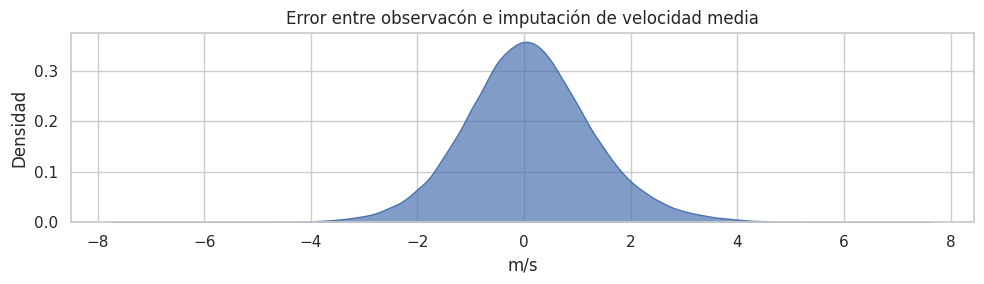

In [87]:
kdeplots_overlay(
    data_aemet,
    ['velmedia_error'],
    figsize=(10, 3),
    title='Error entre observacón e imputación de velocidad media',
    xlabel='m/s',
    legend=False,
)

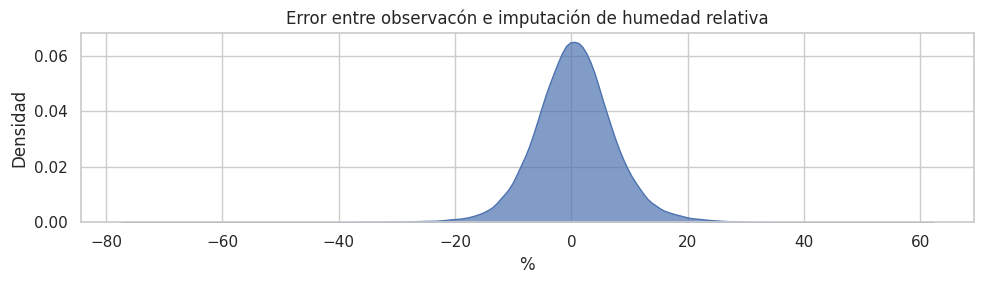

In [88]:
kdeplots_overlay(
    data_aemet,
    ['hrMedia_error'],
    figsize=(10, 3),
    title='Error entre observacón e imputación de humedad relativa',
    xlabel='%',
    legend=False,
)

# hist_overlay(
#     data_aemet,
#     ['hrMedia_error_abs'],
#     figsize=(10, 3),
#     # alpha=0.4,
#     nbins=100,
#     xlabel='%',
#     title='Error absoluto entre observacón e imputación de humedad relativa',
#     legend=False,
# )

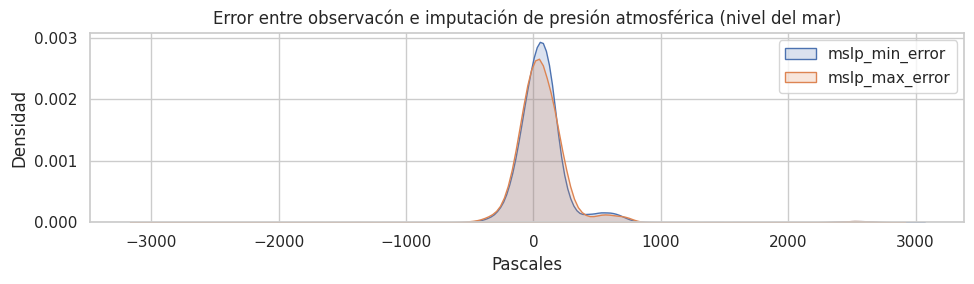

In [97]:
# pascales
kdeplots_overlay(
    data_aemet,
    ['mslp_min_error', 'mslp_max_error'],
    figsize=(10, 3),
    title='Error entre observacón e imputación de presión atmosférica (nivel del mar)',
    xlabel='Pascales',
    alpha=0.2,
)

# hist_overlay(
#     data_aemet,
#     ['mslp_min_error_abs', 'mslp_max_error_abs'],
#     figsize=(10, 3),
#     alpha=0.6,
#     nbins=100,
#     title='Error absoluto entre observacón e imputación de presión atmosférica (nivel del mar)',
#     xlabel='Pascales'
# )

#### 4.5.2.3. Diferencias en la distribución dados los mismos registros

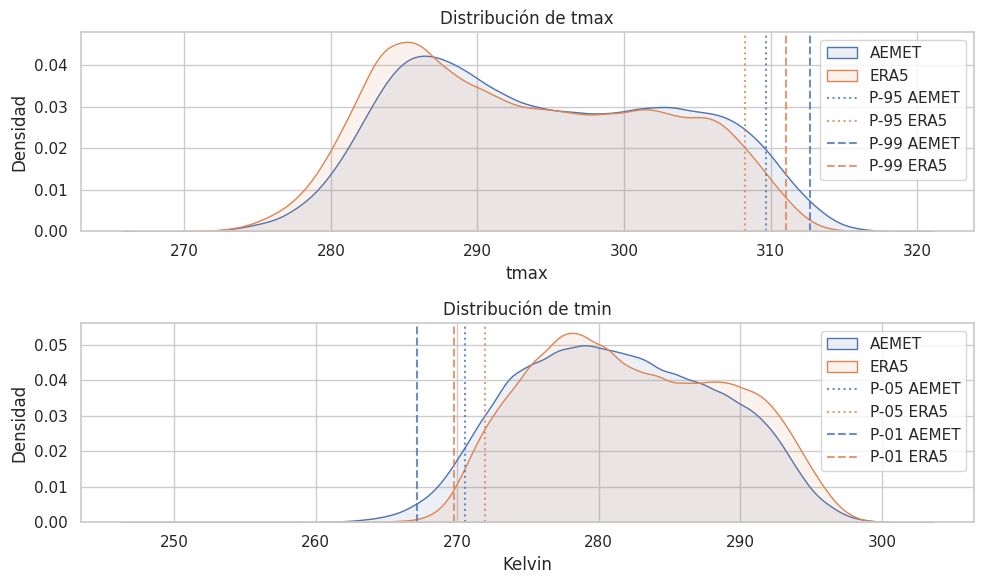

In [101]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

blue = sns.color_palette("deep")[0]
orange = sns.color_palette("deep")[1]

# tmax
sns.kdeplot(data=data_aemet['tmax'], label='AEMET', fill=True, alpha=0.1, ax=axes[0])
sns.kdeplot(data=data_aemet['tmax'] + data_aemet['tmax_error'], label='ERA5', fill=True, alpha=0.1, ax=axes[0])

p95_tmax_aemet = data_aemet['tmax'].quantile(0.95)
p95_tmax_era5 = (data_aemet['tmax'] + data_aemet['tmax_error']).quantile(0.95)
p99_tmax_aemet = data_aemet['tmax'].quantile(0.99)
p99_tmax_era5 = (data_aemet['tmax'] + data_aemet['tmax_error']).quantile(0.99)

axes[0].axvline(p95_tmax_aemet, color=blue, linestyle=':', label='P-95 AEMET', alpha=0.8)
axes[0].axvline(p95_tmax_era5, color=orange, linestyle=':', label='P-95 ERA5', alpha=0.8)
axes[0].axvline(p99_tmax_aemet, color=blue, linestyle='--', label='P-99 AEMET', alpha=0.8)
axes[0].axvline(p99_tmax_era5, color=orange, linestyle='--', label='P-99 ERA5', alpha=0.8)

axes[0].set_title('Distribución de tmax')
axes[0].set_ylabel('Densidad')
# axes[0].set_xlabel('Kelvin')
axes[0].legend()


# tmin
sns.kdeplot(data=data_aemet['tmin'], label='AEMET', fill=True, alpha=0.1, ax=axes[1])
sns.kdeplot(data=data_aemet['tmin'] + data_aemet['tmin_error'], label='ERA5', fill=True, alpha=0.1, ax=axes[1])

p95_tmin_aemet = data_aemet['tmin'].quantile(0.05)
p95_tmin_era5 = (data_aemet['tmin'] + data_aemet['tmin_error']).quantile(0.05)
p99_tmin_aemet = data_aemet['tmin'].quantile(0.01)
p99_tmin_era5 = (data_aemet['tmin'] + data_aemet['tmin_error']).quantile(0.01)

axes[1].axvline(p95_tmin_aemet, color=blue, linestyle=':', label='P-05 AEMET', alpha=0.8)
axes[1].axvline(p95_tmin_era5, color=orange, linestyle=':', label='P-05 ERA5', alpha=0.8)
axes[1].axvline(p99_tmin_aemet, color=blue, linestyle='--', label='P-01 AEMET', alpha=0.8)
axes[1].axvline(p99_tmin_era5, color=orange, linestyle='--', label='P-01 ERA5', alpha=0.8)

axes[1].set_title('Distribución de tmin')
axes[1].set_ylabel('Densidad')
axes[1].set_xlabel('Kelvin')
axes[1].legend()

plt.tight_layout()
plt.show()

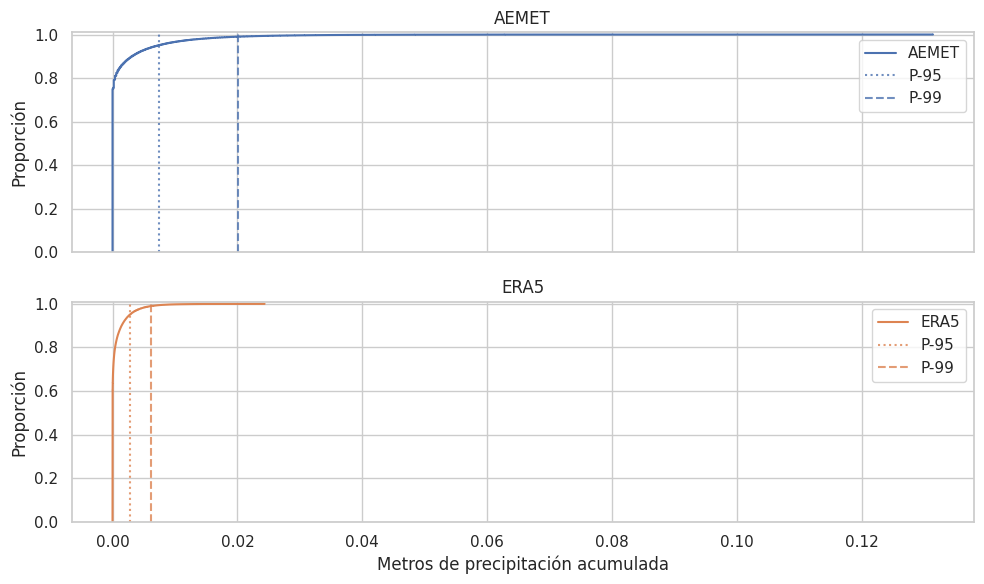

In [100]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# AEMET
sns.ecdfplot(
    data=data_aemet['prec'],
    ax=axes[0],
    color=blue,
    label='AEMET'
)

p95_aemet = data_aemet['prec'].quantile(0.95)
axes[0].axvline(p95_aemet, color=blue, linestyle=':', label='P-95', alpha=0.8)
p99_aemet = data_aemet['prec'].quantile(0.99)
axes[0].axvline(p99_aemet, color=blue, linestyle='--', label='P-99', alpha=0.8)


axes[0].set_title('AEMET')
axes[0].legend()
axes[0].set_ylim([0, 1.01])
axes[0].set_ylabel('Proporción')


# ERA5
sns.ecdfplot(
    data=(data_aemet['prec'] + data_aemet['prec_error']),
    ax=axes[1],
    color=orange,
    label='ERA5'
)

p95_era5 = (data_aemet['prec'] + data_aemet['prec_error']).quantile(0.95)
axes[1].axvline(p95_era5, color=orange, linestyle=':', label='P-95', alpha=0.8)
p99_era5 = (data_aemet['prec'] + data_aemet['prec_error']).quantile(0.99)
axes[1].axvline(p99_era5, color=orange, linestyle='--', label='P-99', alpha=0.8)

axes[1].set_title('ERA5')
axes[1].legend()
axes[1].set_ylim([0, 1.01])
axes[1].set_ylabel('Proporción')
axes[1].set_xlabel('Metros de precipitación acumulada')

plt.tight_layout()
plt.show()

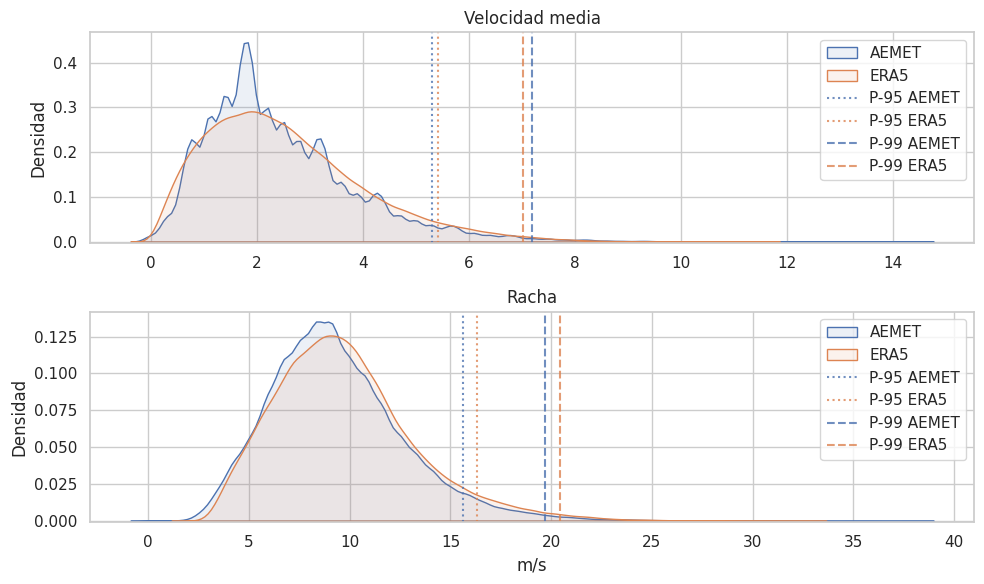

In [102]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)


# velmedia
sns.kdeplot(
    data=data_aemet['velmedia'],
    label='AEMET',
    fill=True,
    alpha=0.1,
    ax=axes[0]
)
sns.kdeplot(
    data=(data_aemet['velmedia'] + data_aemet['velmedia_error']),
    label='ERA5',
    fill=True,
    alpha=0.1,
    ax=axes[0]
)

p95_vel_aemet = data_aemet['velmedia'].quantile(0.95)
p95_vel_era5 = (data_aemet['velmedia'] + data_aemet['velmedia_error']).quantile(0.95)
p99_vel_aemet = data_aemet['velmedia'].quantile(0.99)
p99_vel_era5 = (data_aemet['velmedia'] + data_aemet['velmedia_error']).quantile(0.99)

axes[0].axvline(p95_vel_aemet, color=blue, linestyle=':', label='P-95 AEMET', alpha=0.8)
axes[0].axvline(p95_vel_era5, color=orange, linestyle=':', label='P-95 ERA5', alpha=0.8)

axes[0].axvline(p99_vel_aemet, color=blue, linestyle='--', label='P-99 AEMET', alpha=0.8)
axes[0].axvline(p99_vel_era5, color=orange, linestyle='--', label='P-99 ERA5', alpha=0.8)

axes[0].set_title('Velocidad media')
axes[0].legend()
axes[0].set_ylabel('Densidad')
axes[0].set_xlabel("")
axes[0].set_ylim(-0.003)

# racha
sns.kdeplot(
    data=data_aemet['racha'],
    label='AEMET',
    fill=True,
    alpha=0.1,
    ax=axes[1]
)
sns.kdeplot(
    data=(data_aemet['racha'] + data_aemet['racha_error']),
    label='ERA5',
    fill=True,
    alpha=0.1,
    ax=axes[1]
)

p95_racha_aemet = data_aemet['racha'].quantile(0.95)
p95_racha_era5 = (data_aemet['racha'] + data_aemet['racha_error']).quantile(0.95)
p99_racha_aemet = data_aemet['racha'].quantile(0.99)
p99_racha_era5 = (data_aemet['racha'] + data_aemet['racha_error']).quantile(0.99)

axes[1].axvline(p95_racha_aemet, color=blue, linestyle=':', label='P-95 AEMET', alpha=0.8)
axes[1].axvline(p95_racha_era5, color=orange, linestyle=':', label='P-95 ERA5', alpha=0.8)

axes[1].axvline(p99_racha_aemet, color=blue, linestyle='--', label='P-99 AEMET', alpha=0.8)
axes[1].axvline(p99_racha_era5, color=orange, linestyle='--', label='P-99 ERA5', alpha=0.8)

axes[1].set_title('Racha')
axes[1].legend()
axes[1].set_ylabel('Densidad')
axes[1].set_xlabel('m/s')
axes[1].set_ylim(-0.001)

plt.tight_layout()
plt.show()

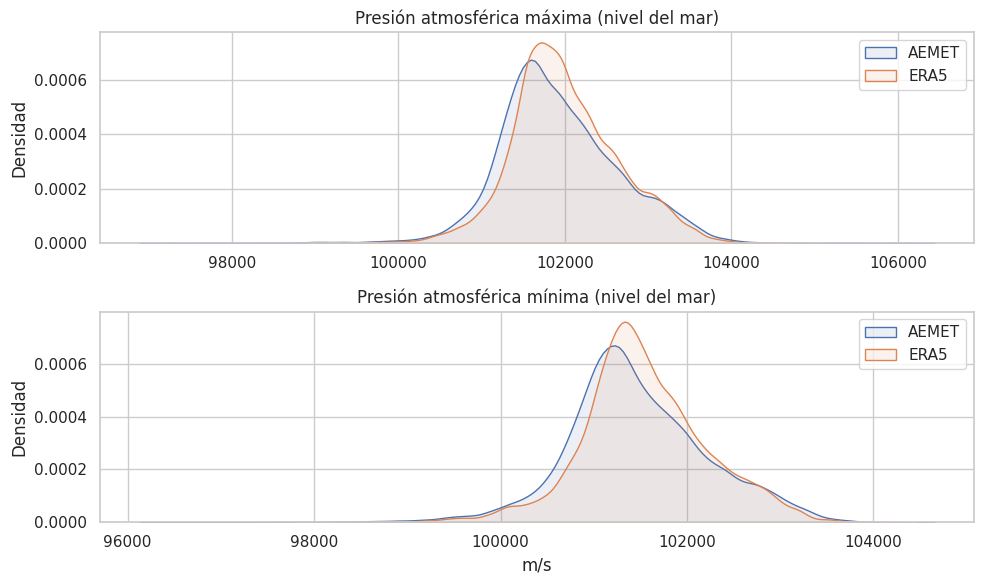

In [103]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

# data_aemet_sub = data_aemet[data_aemet['altitud'] <= 750]
data_aemet_sub = data_aemet.copy()

sns.kdeplot(
    data=data_aemet_sub['mslp_max'],
    label='AEMET',
    fill=True,
    alpha=0.1,
    ax=axes[0]
)
sns.kdeplot(
    data=(data_aemet_sub['mslp_max'] + data_aemet_sub['mslp_max_error']),
    label='ERA5',
    fill=True,
    alpha=0.1,
    ax=axes[0]
)

axes[0].set_title('Presión atmosférica máxima (nivel del mar)')
axes[0].legend()
axes[0].set_ylabel('Densidad')
axes[0].set_xlabel("")
# axes[0].set_ylim(-0.003)

sns.kdeplot(
    data=data_aemet_sub['mslp_min'],
    label='AEMET',
    fill=True,
    alpha=0.1,
    ax=axes[1]
)
sns.kdeplot(
    data=(data_aemet_sub['mslp_min'] + data_aemet_sub['mslp_min_error']),
    label='ERA5',
    fill=True,
    alpha=0.1,
    ax=axes[1]
)

axes[1].set_title('Presión atmosférica mínima (nivel del mar)')
axes[1].legend()
axes[1].set_ylabel('Densidad')
axes[1].set_xlabel('m/s')
# axes[1].set_ylim(-0.001)

plt.tight_layout()
plt.show()

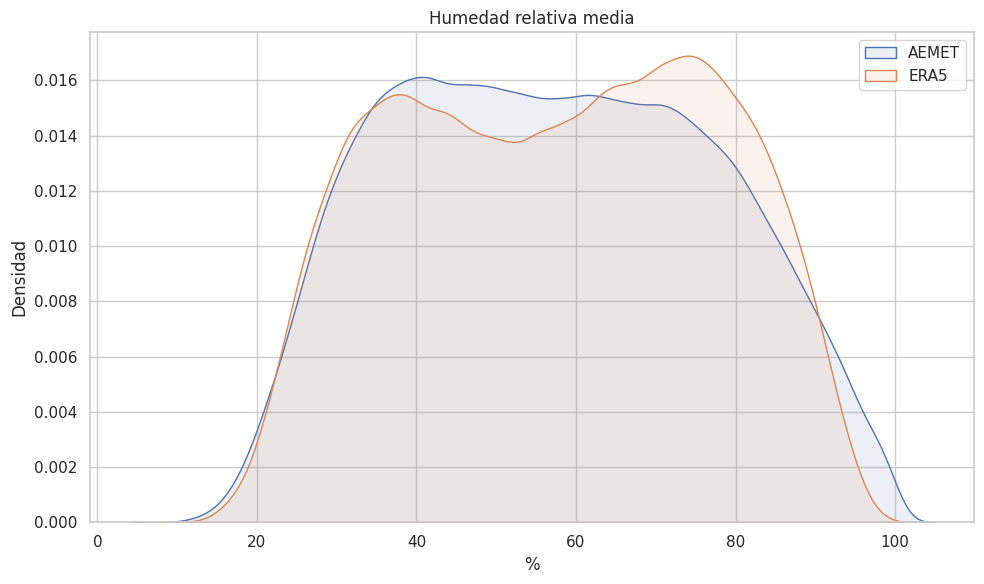

In [104]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=False)

sns.kdeplot(
    data=data_aemet['hrMedia'],
    label='AEMET',
    fill=True,
    alpha=0.1,
    ax=axes
)
sns.kdeplot(
    data=(data_aemet['hrMedia'] + data_aemet['hrMedia_error']),
    label='ERA5',
    fill=True,
    alpha=0.1,
    ax=axes
)

axes.set_title('Humedad relativa media')
axes.legend()
axes.set_ylabel('Densidad')
axes.set_xlabel("%")

plt.tight_layout()
plt.show()

## 4.6. Conclusión

Se observa que hay diferencias entre los percentiles de ambos datos, aunque en las diferencias de thresholds observadas tras la imputación, no se advierte una diferencia excesiva. Se usarán los de ERA5 para el cálculo de thresholds porque la diferencia advertida en los umbrales tras su adición no es demasiado alta en la mayoría de los casos y porque en caso contrario habrá miles de registros sin threshold.